In [1]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

with open('../preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_normal'].values
X_test  = data['X_test'].values
y_test  = data['y_test']
print('Data loaded. Train:', X_train.shape, '| Test:', X_test.shape)

Data loaded. Train: (6358, 16) | Test: (3642, 16)


In [2]:
print('\nTraining Isolation Forest on Normal data only...')
iso = IsolationForest(n_estimators=300, contamination=0.05,
                      random_state=42, n_jobs=-1)
iso.fit(X_train)

iso_scores = -iso.score_samples(X_test)
iso_preds  = (iso.predict(X_test) == -1).astype(int)

print('\n=== Isolation Forest ===')
print(classification_report(y_test, iso_preds,
      target_names=['Normal', 'Anomaly'], digits=4))
iso_auc = roc_auc_score(y_test, iso_scores)
iso_apr = average_precision_score(y_test, iso_scores)
iso_f1  = f1_score(y_test, iso_preds)
print(f'AUC-ROC: {iso_auc:.4f} | AUC-PR: {iso_apr:.4f} | F1: {iso_f1:.4f}')


Training Isolation Forest on Normal data only...



=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal     0.4390    0.9509    0.6007      1590
     Anomaly     0.6061    0.0585    0.1067      2052

    accuracy                         0.4481      3642
   macro avg     0.5225    0.5047    0.3537      3642
weighted avg     0.5331    0.4481    0.3224      3642

AUC-ROC: 0.5069 | AUC-PR: 0.5697 | F1: 0.1067


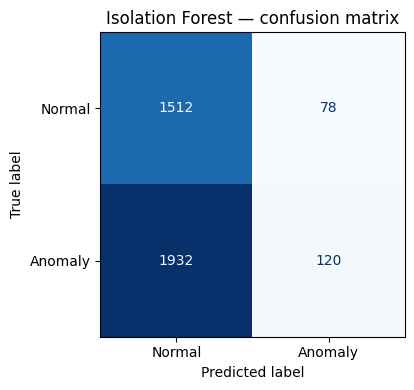

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, iso_preds),
    display_labels=['Normal', 'Anomaly']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Isolation Forest — confusion matrix')
plt.tight_layout()
plt.savefig('../outputs/iso_confusion.png', dpi=150)
plt.show()


Training One-Class SVM (using 3000 sample subset for speed)...

=== One-Class SVM ===
              precision    recall  f1-score   support

      Normal     0.4389    0.9421    0.5988      1590
     Anomaly     0.5983    0.0668    0.1201      2052

    accuracy                         0.4489      3642
   macro avg     0.5186    0.5045    0.3595      3642
weighted avg     0.5287    0.4489    0.3291      3642

AUC-ROC: 0.5124 | AUC-PR: 0.5758 | F1: 0.1201


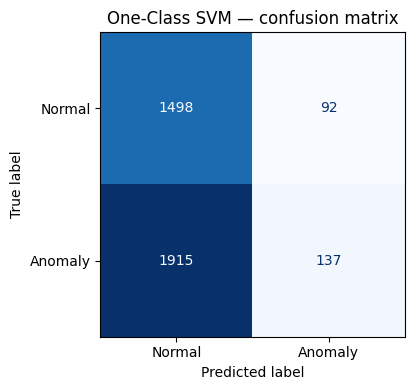

In [4]:
print('\nTraining One-Class SVM (using 3000 sample subset for speed)...')
X_sub = X_train[:3000]

ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(X_sub)

ocsvm_scores = -ocsvm.score_samples(X_test)
ocsvm_preds  = (ocsvm.predict(X_test) == -1).astype(int)

print('\n=== One-Class SVM ===')
print(classification_report(y_test, ocsvm_preds,
      target_names=['Normal', 'Anomaly'], digits=4))
ocsvm_auc = roc_auc_score(y_test, ocsvm_scores)
ocsvm_apr = average_precision_score(y_test, ocsvm_scores)
ocsvm_f1  = f1_score(y_test, ocsvm_preds)
print(f'AUC-ROC: {ocsvm_auc:.4f} | AUC-PR: {ocsvm_apr:.4f} | F1: {ocsvm_f1:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, ocsvm_preds),
    display_labels=['Normal', 'Anomaly']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('One-Class SVM — confusion matrix')
plt.tight_layout()
plt.savefig('../outputs/ocsvm_confusion.png', dpi=150)
plt.show()

In [5]:
data['iso_model']    = iso
data['iso_scores']   = iso_scores
data['iso_preds']    = iso_preds
data['ocsvm_model']  = ocsvm
data['ocsvm_scores'] = ocsvm_scores
data['ocsvm_preds']  = ocsvm_preds

with open('../preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print('\nSaved. Run notebook 3 next.')


Saved. Run notebook 3 next.
